In [109]:
import numpy as np
import matplotlib.pyplot as plt

In [110]:
width, height = 800, 800
xmin, xmax = -1.5, 1.5
ymin, ymax = -1.5, 1.5

x = np.linspace(xmin, xmax, width) #evenly coordinated spaces
y = np.linspace(ymin, ymax, height)
print("x\n",x[:5])
print("y\n",y[:5])
X, Y = np.meshgrid(x, y) #expand 1D lists to 2D grid
print("X\n",X[:5,:5])
print("Y\n",Y[:5,:5])
print(x.shape,y.shape,X.shape,Y.shape)
Z = X + 1j * Y #one complex number per pixel

x
 [-1.5        -1.49624531 -1.49249061 -1.48873592 -1.48498123]
y
 [-1.5        -1.49624531 -1.49249061 -1.48873592 -1.48498123]
X
 [[-1.5        -1.49624531 -1.49249061 -1.48873592 -1.48498123]
 [-1.5        -1.49624531 -1.49249061 -1.48873592 -1.48498123]
 [-1.5        -1.49624531 -1.49249061 -1.48873592 -1.48498123]
 [-1.5        -1.49624531 -1.49249061 -1.48873592 -1.48498123]
 [-1.5        -1.49624531 -1.49249061 -1.48873592 -1.48498123]]
Y
 [[-1.5        -1.5        -1.5        -1.5        -1.5       ]
 [-1.49624531 -1.49624531 -1.49624531 -1.49624531 -1.49624531]
 [-1.49249061 -1.49249061 -1.49249061 -1.49249061 -1.49249061]
 [-1.48873592 -1.48873592 -1.48873592 -1.48873592 -1.48873592]
 [-1.48498123 -1.48498123 -1.48498123 -1.48498123 -1.48498123]]
(800,) (800,) (800, 800) (800, 800)


[[-1.5       -1.5j        -1.49624531-1.5j        -1.49249061-1.5j
  ...  1.49249061-1.5j         1.49624531-1.5j
   1.5       -1.5j       ]
 [-1.5       -1.49624531j -1.49624531-1.49624531j -1.49249061-1.49624531j
  ...  1.49249061-1.49624531j  1.49624531-1.49624531j
   1.5       -1.49624531j]
 [-1.5       -1.49249061j -1.49624531-1.49249061j -1.49249061-1.49249061j
  ...  1.49249061-1.49249061j  1.49624531-1.49249061j
   1.5       -1.49249061j]
 ...
 [-1.5       +1.49249061j -1.49624531+1.49249061j -1.49249061+1.49249061j
  ...  1.49249061+1.49249061j  1.49624531+1.49249061j
   1.5       +1.49249061j]
 [-1.5       +1.49624531j -1.49624531+1.49624531j -1.49249061+1.49624531j
  ...  1.49249061+1.49624531j  1.49624531+1.49624531j
   1.5       +1.49624531j]
 [-1.5       +1.5j        -1.49624531+1.5j        -1.49249061+1.5j
  ...  1.49249061+1.5j         1.49624531+1.5j
   1.5       +1.5j       ]]
(800, 800)
i,escaped 0 [[ True  True  True ...  True  True  True]
 [ True  True  True ...  T

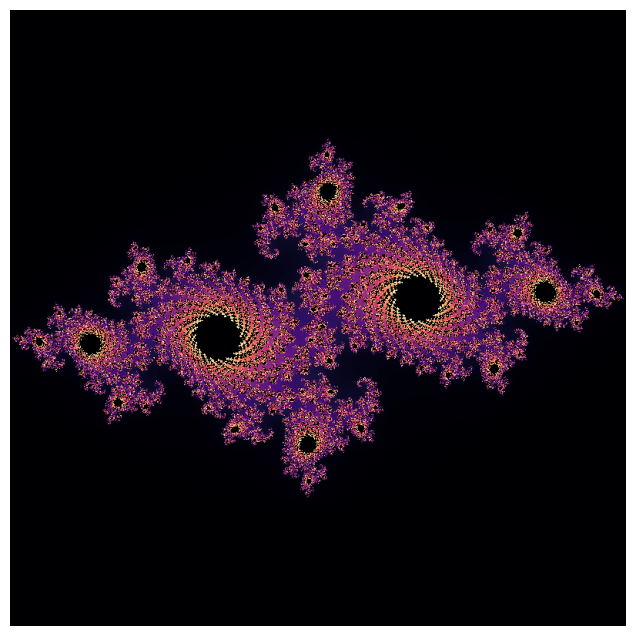

In [111]:
#c=-0.4+0.6j
#c=-0.8+0.156j
#c=-0.285+0.01j
c=-0.7269+0.1889j
#c=-0.4+0.6j

max_iter = 300

Z = Z.copy()
print(Z)
print(Z.shape)

escape = np.zeros(Z.shape, dtype=int) #records iteration number at which each pixel escapes, this becomes color
mask = np.ones(Z.shape, dtype=bool) #not escaped points. only update these values

#print(escape.shape)
#print(mask)

for i in range(max_iter):
    Z[mask] = Z[mask] ** 2 + c #boolean indexing
    escaped = mask & (np.abs(Z) > 2)
    print("i,escaped",i,escaped)
    escape[escaped] = i
    mask[escaped] = False

plt.figure(figsize=(8, 8))
plt.imshow(escape, cmap='magma', extent=[xmin, xmax, ymin, ymax])
plt.axis('off')
plt.show()